## Importación de librerías


In [529]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clustering
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# DuckDB, librería de lectura SQL optimizada, para agilizar la transformación de variables
import duckdb as ddb

# NuestrasFunciones, repertorio de fórmulas compartido por el profesor Guillermo Villarino en la asignatura Minería de datos y Modelización predictiva
from Formulas.NuestrasFuncionesRed import scree_plot_kmeans

import Formulas.FuncionesPropias as propias

In [530]:
# Datasets trabajados en el cuaderno anterior
Municipios = pd.read_csv('Datos procesados/MunicipiosGeo.csv', sep=';', encoding='UTF-8')
ProvinciasGeo = pd.read_csv('Datos procesados/ProvinciasGeo.csv', sep=';', encoding='UTF-8')
PuntosTuristicos = pd.read_csv('Datos procesados/PuntosTuristicos.csv', sep=';', encoding='UTF-8')

# Datos extraidos de la API, que no necesitaron limpieza de datos en el cuaderno anterior
OfertaProv = pd.read_csv('Extractor/data/processed/eoh_oferta_provincias.csv', sep=',', encoding='UTF-8')
OfertaRural = pd.read_csv('Extractor/data/processed/rural_oferta_provincias.csv', sep=',', encoding='UTF-8')
DemandaRural = pd.read_csv('Extractor/data/processed/rural_demanda_provincias.csv', sep=',', encoding='UTF-8')

# Oferta de OpenStreetMap, que no requiere de limpieza. Archivo parquet ya que contiene muchas más filas
OfertaOSM = pd.read_parquet("Datos procesados/pois_espana_osm.parquet")

# Mapa de municipios. 
# Agradecimientos al profesor Lorenzo Escot por adjuntar este mapa dentro del temario de "Minería de datos y modelización predictiva"
Map_muni = gpd.read_file('cartografias/Munic04_ESP.shp')

En primer lugar, vamos a revisar los tres dataframes extraidos directamente de la API.

En el caso de `OfertaOSM`, tabla con 170.000 registros, nos dará dos utilidades muy diferenciadoras. 

En primer lugar, al realizar agrupaciones por provincias tendremos los POIs (_Points Of Interest_) diferenciados en su categoría y subtipo, aunque por simplificar emplearemos unicamente la categoria (Para un trabajo empresarial son datos a tener en cuenta). Cabe mencionar que tambien es posible extraer desde la API el teléfono y pagina web (si hubiera) de cada uno de estos puntos.

En segundo lugar, al elaborar el dashboard porder aprovechar la columna de geometry para localizar todos estos puntos puede ser muy provechoso.

In [531]:
print(f'filas y columnas de OfertaOSM: {OfertaOSM.shape}')
print(' ')
OfertaOSM.head()

filas y columnas de OfertaOSM: (170939, 14)
 


,osm_id,osm_type,categoria,subtipo,nombre,cod_prov,provincia,latitud,longitud,estrellas,capacidad,municipio,codigo_postal,geometry_wkt
0,101331675,node,Ocio y Naturaleza,attraction,Sorginetxe trikuharria,01,Araba/Álava,42.829550,-2.378238,NaN,NaN,NaN,NaN,POINT (-2.378238 42.82955)
1,257921865,node,Alojamiento,hotel,400,01,Araba/Álava,42.842796,-2.670601,NaN,NaN,NaN,NaN,POINT (-2.670601 42.842796)
2,315898522,node,Restauracion,restaurant,Urtegi-alde,01,Araba/Álava,42.953143,-2.650224,NaN,NaN,NaN,NaN,POINT (-2.650224 42.953143)
3,392302250,node,Alojamiento,hotel,Dato,01,Araba/Álava,42.843640,-2.672684,2,14,NaN,NaN,POINT (-2.672684 42.84364)
4,392302251,node,Alojamiento,hotel,abba Jazz Hotel,01,Araba/Álava,42.843579,-2.675009,3,NaN,Vitoria-Gasteiz,01005,POINT (-2.675009 42.843579)


Pivotamos ``OfertaOSM`` por ``categoria``

In [532]:
OfertaOSM = OfertaOSM.pivot_table(
    index=['cod_prov', 'provincia'],
    columns='categoria',
    values='osm_id',
    aggfunc='count',
    fill_value=0
).reset_index()

OfertaOSM.columns = OfertaOSM.columns.str.replace({'Cultura y Patrimonio':'Cultura',
                                                   'Ocio y Naturaleza': 'Ocio'
                                                   })

OfertaOSM.head()

categoria,cod_prov,provincia,Alojamiento,Cultura,Ocio,Restauracion,Servicios Turisticos,Turismo General
0,01,Araba/Álava,136,137,165,1033,5,0
1,02,Albacete,202,90,146,649,0,0
2,03,Alicante/Alacant,727,430,498,5145,10,0
3,04,Almería,307,188,247,1388,7,0
4,05,Ávila,246,106,127,437,7,0


Como los dataframes no trabajados anteriormente poseen un eje temporal de 24 meses, debemos quedarnos con los ultimos 12 meses, por lo que usaremos la formula propia de ``crear_fecha()``, y despues filtraremos por los ultimos meses.

In [533]:
#Creamos la fecha para filtrar
OfertaProv = propias.crear_fecha(OfertaProv)
OfertaRural = propias.crear_fecha(OfertaRural)
DemandaRural = propias.crear_fecha(DemandaRural)

# Definimos fecha corte para tener un filtro dinámico
fecha_corte = OfertaProv['Fecha'].max() - pd.DateOffset(months=11) # Como los tres df contienen los mismos meses, esta variable nos servirá para los tres

OfertaProv = OfertaProv[OfertaProv['Fecha'] >= fecha_corte].reset_index(drop=True)
OfertaRural = OfertaRural[OfertaRural['Fecha'] >= fecha_corte].reset_index(drop=True)
DemandaRural= DemandaRural[DemandaRural['Fecha'] >= fecha_corte].reset_index(drop=True)

print(f"""COMPROBACION:
      La fecha de corte es: {fecha_corte}
      La fecha mas reciente es {OfertaProv['Fecha'].max()}
      La fecha mas antigua tras filtrar es {OfertaProv['Fecha'].min()}""")


COMPROBACION:
      La fecha de corte es: 2025-08-01 00:00:00
      La fecha mas reciente es 2026-07-01 00:00:00
      La fecha mas antigua tras filtrar es 2025-08-01 00:00:00


In [534]:
OfertaProv.describe().round(2)

,COD_PROV,Anyo,establecimientos_abiertos,grado_ocupacion_finsemana,grado_ocupacion_habitaciones,grado_ocupacion_plazas,plazas_estimadas,Fecha
count,624.00,624.00,624.00,624.00,624.00,624.00,624.00,624
mean,26.50,2025.58,286.52,55.11,55.73,46.75,30795.41,2026-01-15 10:00:00
min,1.00,2025.00,6.00,20.33,22.47,17.63,536.00,2025-08-01 00:00:00
25%,13.75,2025.00,138.00,45.06,43.46,35.38,6733.50,2025-10-24 06:00:00
50%,26.50,2026.00,197.50,54.98,53.92,44.32,11532.50,2026-01-16 12:00:00
75%,39.25,2026.00,341.25,65.08,66.78,56.14,28298.50,2026-04-08 12:00:00
max,52.00,2026.00,1381.00,88.69,91.66,89.61,379728.00,2026-07-01 00:00:00
std,15.02,0.49,259.66,13.42,15.42,14.61,50155.60,NaN


In [535]:
OfertaRural.describe().round(2)

,COD_PROV,Anyo,establecimientos_abiertos,grado_ocupacion_finsemana,grado_ocupacion_habitaciones,grado_ocupacion_plazas,plazas_estimadas,Fecha
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600
mean,25.50,2025.58,329.98,33.24,26.26,19.75,3304.14,2026-01-15 10:00:00
min,1.00,2025.00,34.00,7.60,3.77,3.15,476.00,2025-08-01 00:00:00
25%,13.00,2025.00,158.00,25.69,17.52,12.74,1615.75,2025-10-24 06:00:00
50%,25.50,2026.00,241.00,32.62,22.84,16.90,2632.00,2026-01-16 12:00:00
75%,38.00,2026.00,430.75,39.32,30.12,22.94,4155.25,2026-04-08 12:00:00
max,50.00,2026.00,1634.00,69.66,82.83,73.08,15427.00,2026-07-01 00:00:00
std,14.44,0.49,254.16,10.90,13.57,11.19,2443.59,NaN


In [536]:
DemandaRural.describe().round(2)

,COD_PROV,Anyo,pernoctaciones,viajeros,Fecha
count,600.00,600.00,600.00,600.00,600
mean,25.50,2025.58,15208.70,6156.37,2026-01-15 10:00:00
min,1.00,2025.00,687.00,409.00,2025-08-01 00:00:00
25%,13.00,2025.00,5868.00,2646.50,2025-10-24 06:00:00
50%,25.50,2026.00,10306.50,4347.00,2026-01-16 12:00:00
75%,38.00,2026.00,19367.00,8321.25,2026-04-08 12:00:00
max,50.00,2026.00,223120.00,51928.00,2026-07-01 00:00:00
std,14.44,0.49,18169.82,5613.67,NaN


Tras revisar estos datos podemos determinar que estas tres tablas nos dan información muy relevante para construir la imagen referente a la oferta y demanda turística a nivel provincial, estimadores muy necesarios para medir la saturación y madurez de cada zona

Respecto a los puntos turísticos, analizados en el notebook anterior, podemos determinar que se miden a nivel municipal, centrandose en 104 municipios con una alta madurez turística, quedando pendiente su nivel de saturación. 

In [537]:
PuntosTuristicos.head()

,COD_INE,LOCALIDAD,VALOR PERNOCTACIONES EXTRANJERO,VALOR PERNOCTACIONES NACIONAL,VALOR VIAJERO EXTRANJERO,VALOR VIAJERO NACIONAL,PERIODO PERNOCTACIONES EXTRANJERO,PERIODO PERNOCTACIONES NACIONAL,PERIODO VIAJERO EXTRANJERO,PERIODO VIAJERO NACIONAL
0,3018,Altea,365608.0,291281.0,109312.0,136312.0,M09,M08,M05,M08
1,4032,Carboneras,9895.0,109766.0,4273.0,46406.0,M09,M08,M09,M07
2,4902,"Ejido, El",25776.0,52671.0,7614.0,18840.0,M08,M08,M08,M08
3,7003,Alcúdia,7562818.0,365652.0,1177676.0,88693.0,M08,M09,M08,M09
4,7015,Ciutadella de Menorca,3700172.0,709456.0,567668.0,165448.0,M08,M08,M08,M08


A continuación, tendremos que definir bien el tipo de dato de nuestros datos, comenzaremos con una revisión del tipo de dato

In [538]:
Columnas = ['COD_PROV', 'cod_ine', 'CODINE_MU']
Map_muni[Columnas] = Map_muni[Columnas].astype('Int64')

In [539]:
Map_prov = Map_muni[['COD_PROV', 'PROV','CCAA', 'geometry']].dissolve(by='COD_PROV', as_index=False) #Comprimimos el mapa por provincia

Map_prov.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   COD_PROV  52 non-null     Int64   
 1   geometry  52 non-null     geometry
 2   PROV      52 non-null     str     
 3   CCAA      52 non-null     str     
dtypes: Int64(1), geometry(1), str(2)
memory usage: 2.9 KB


Comprobamos que `cod_ine` y `CODINE_MU` contienen los mismos valores. si la siguiente celda muestra como resultado 0, entonces todas serán idénticas

In [540]:
# Comprobamos
print( f'Número de valores diferentes en variables mencionadas: {Map_muni[Map_muni['cod_ine'] != Map_muni['CODINE_MU']].shape[0]}')

Número de valores diferentes en variables mencionadas: 0


Al validar que son el mismo dato, la incluimos en la lista de variables que queremos eliminar para ahorrar memoria y simplificar

In [541]:
Map_muni = Map_muni.drop(columns= ['PROV','CCAA',
                                   'SP_ID','id',
                                   'POB_2016','POB_HO',
                                   'POB_MU','PARO_TO',
                                   'POB16_64','TASA_PARO',
                                   'RENTPCAP07', 'PrecioIn16']) # Eliminamos columnas que para este proyecto no son de interés
Map_muni.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   cod_ine    8108 non-null   Int64   
 1   CODINE_MU  8108 non-null   Int64   
 2   COD_PROV   8108 non-null   Int64   
 3   MUN        8108 non-null   str     
 4   geometry   8108 non-null   geometry
dtypes: Int64(3), geometry(1), str(1)
memory usage: 440.0 KB


In [542]:
ProvinciasGeo.head()

,COD_PROV,PROVINCIA,COD_CA,COMUNIDAD_AUTONOMA,CAPITAL,Perc_Provincia,Perc_VALOR PERNOCTACIONES,Perc_VALOR VIAJERO,Perc_PERIODO PERNOCTACIONES,Perc_PERIODO VIAJERO,...,cod_prov,Metricas_provincia,Metricas_poblacion,Metricas_total_viajeros,Metricas_media_mensual_viajeros,Metricas_std_mensual_viajeros,Metricas_presion_turistica,Metricas_indice_estacionalidad,Metricas_n_meses,Metricas__meta.fecha_extraccion
0,1,Araba/Álava,16,País Vasco/Euskadi,Vitoria-Gasteiz,Alava,2208517.0,1027118.0,M08,M08,...,1,Araba/Álava,333626.0,495295.0,41274.583333,8518.068085,1.484582,0.206376,12,2026-09-06T23:46:39.776749
1,2,Albacete,8,Castilla-La Mancha,Albacete,Albacete,1737927.0,842801.0,M09,M09,...,2,Albacete,386464.0,409581.0,34131.750000,6452.276795,1.059817,0.189040,12,2026-09-06T23:46:39.776749
2,3,Alacant/Alicante,10,Comunitat Valenciana,Alacant/Alicante,Alicante,37680371.0,10134012.0,M08,M08,...,3,Alicante/Alacant,1881762.0,5100916.0,425076.333333,112189.627548,2.710713,0.263928,12,2026-09-06T23:46:39.776749
3,4,Almería,1,Andalucía,Almería,Almería,10606166.0,3125996.0,M08,M08,...,4,Almería,731792.0,1585364.0,132113.666667,81085.945400,2.166413,0.613759,12,2026-09-06T23:46:39.776749
4,5,Ávila,7,Castilla y León,Ávila,Avila,1243810.0,781100.0,M08,M08,...,5,Ávila,158421.0,394330.0,32860.833333,6580.058135,2.489127,0.200240,12,2026-09-06T23:46:39.776749


In [543]:
ProvinciasGeo = ProvinciasGeo.drop(columns=['COD_INE',
                                            'CAPITAL','Perc_Provincia',
                                            'Ratios_Provincia',
                                            'Metricas_provincia', 'cod_prov',
                                            'Metricas_n_meses','Metricas__meta.fecha_extraccion'])

ProvinciasGeo.head(2)

,COD_PROV,PROVINCIA,COD_CA,COMUNIDAD_AUTONOMA,Perc_VALOR PERNOCTACIONES,Perc_VALOR VIAJERO,Perc_PERIODO PERNOCTACIONES,Perc_PERIODO VIAJERO,Ratios_Periodo ADR Dato,Ratios_Periodo ADR Tasa de variacin interanual,...,Ratios_Valor ADR Tasa de variacin interanual,Ratios_Valor Ingresos por habitacin disponible RevPAR Dato,Ratios_Valor Ingresos por habitacin disponible RevPAR Tasa de variacin interanual,Ratios_ADR Anual Medio,Metricas_poblacion,Metricas_total_viajeros,Metricas_media_mensual_viajeros,Metricas_std_mensual_viajeros,Metricas_presion_turistica,Metricas_indice_estacionalidad
0,1,Araba/Álava,16,País Vasco/Euskadi,2208517.0,1027118.0,M08,M08,M07,M06,...,13.91,89.31,27.88,92.070833,333626.0,495295.0,41274.583333,8518.068085,1.484582,0.206376
1,2,Albacete,8,Castilla-La Mancha,1737927.0,842801.0,M09,M09,M09,M11,...,20.13,50.10,54.79,66.487500,386464.0,409581.0,34131.750000,6452.276795,1.059817,0.189040


Comprobamos valores únicos en `Municipios` para comprobar qué columnas eliminar

In [544]:
Municipios.nunique()

COD_INE                     8132
COD_GEO                     8124
COD_PROV                      52
PROVINCIA                     52
NOMBRE_ACTUAL               8115
POBLACION_MUNI              3567
SUPERFICIE                  8128
PERIMETRO                   7599
COD_INE_CAPITAL             8132
CAPITAL                     8069
POBLACION_CAPITAL           3104
LONGITUD_ETRS89_REGCAN95    8132
LATITUD_ETRS89_REGCAN95     8131
ALTITUD                     1372
COD_CA                        19
COMUNIDAD_AUTONOMA            19
Personas_Valor              3572
Personas_Localidad          8115
Personas_Genero                1
Personas_Metrica               1
Personas_Unidad                1
dtype: int64

Eliminamos columnas no necesarias. Se incluye Longitud y Latitud ya que en los GeoDataFrames revisados anteriormente ya tenemos una columna `geometry` para municipios y provincias

In [545]:
# Drop de columnas que no necesitamos, para ahorrar recursos
# Como ya tenemos en  
Municipios = Municipios.drop(columns=['COD_GEO',
                                      'COD_INE_CAPITAL', 'CAPITAL',
                                      'Personas_Localidad', 'Personas_Genero',
                                      'Personas_Metrica', 'Personas_Unidad',
                                      'LONGITUD_ETRS89_REGCAN95', 'LATITUD_ETRS89_REGCAN95'])

print(Municipios.info())


<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COD_INE             8132 non-null   int64  
 1   COD_PROV            8132 non-null   int64  
 2   PROVINCIA           8132 non-null   str    
 3   NOMBRE_ACTUAL       8132 non-null   str    
 4   POBLACION_MUNI      8132 non-null   int64  
 5   SUPERFICIE          8132 non-null   str    
 6   PERIMETRO           8132 non-null   int64  
 7   POBLACION_CAPITAL   8132 non-null   int64  
 8   ALTITUD             8132 non-null   str    
 9   COD_CA              8132 non-null   int64  
 10  COMUNIDAD_AUTONOMA  8132 non-null   str    
 11  Personas_Valor      8132 non-null   float64
dtypes: float64(1), int64(6), str(5)
memory usage: 1.1 MB
None


Definimos fórmula para modificar el tipo de dato a entero, con decimal o categórico

usamos la fórmula de ``cambiar_tipodato()``

In [546]:
colnumeric= ['COD_INE', 'POBLACION_MUNI', 
             'PERIMETRO', 'POBLACION_CAPITAL', 
             'Personas_Valor']
colfloat= ['SUPERFICIE', 'ALTITUD']
colcat = ['COD_PROV', 'COMUNIDAD_AUTONOMA', 'PROVINCIA']

Municipios = propias.cambiar_tipodato(Municipios, colnumeric,colfloat,colcat)

Municipios.info()

<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   COD_INE             8132 non-null   Int64   
 1   COD_PROV            8132 non-null   category
 2   PROVINCIA           8132 non-null   category
 3   NOMBRE_ACTUAL       8132 non-null   str     
 4   POBLACION_MUNI      8132 non-null   Int64   
 5   SUPERFICIE          8132 non-null   Float64 
 6   PERIMETRO           8132 non-null   Int64   
 7   POBLACION_CAPITAL   8132 non-null   Int64   
 8   ALTITUD             8132 non-null   Float64 
 9   COD_CA              8132 non-null   int64   
 10  COMUNIDAD_AUTONOMA  8132 non-null   category
 11  Personas_Valor      8132 non-null   Int64   
dtypes: Float64(2), Int64(5), category(3), int64(1), str(1)
memory usage: 752.5 KB


## Feature engineering

El primer paso del feature engineering será convertir todas esas columnas referentes a meses (con valores por ejemplo M7, M6...) en valores categóricos.

Sin embargo, nos interesa agrupar estos valores en estaciones, por lo que vamos a definir una función para modificar todos estos, ya que aparece en varios df

Los dataframes con estos valores son `ProvinciasGeo`, `PuntosTuristicos`, `OfertaProv`, `OfertaRural` y `DemandaRural`

In [547]:
ProvinciasGeo = propias.estacionador(ProvinciasGeo)
PuntosTuristicos = propias.estacionador(PuntosTuristicos)
OfertaProv = propias.estacionador(OfertaProv)
OfertaRural = propias.estacionador(OfertaRural)
DemandaRural = propias.estacionador(DemandaRural)



#Comprobamos
#PuntosTuristicos.head()
ProvinciasGeo.head(1).T

,0
COD_PROV,1
PROVINCIA,Araba/Álava
COD_CA,16
COMUNIDAD_AUTONOMA,País Vasco/Euskadi
Perc_VALOR PERNOCTACIONES,2208517.0
Perc_VALOR VIAJERO,1027118.0
Perc_PERIODO PERNOCTACIONES,Verano
Perc_PERIODO VIAJERO,Verano
Ratios_Periodo ADR Dato,Verano
Ratios_Periodo ADR Tasa de variacin interanual,Primavera


Previo al siguiente paso, vamos a reescribir el nombre de las columnas a minúsculas, para mejorar la lectura humana de la consulta SQL

In [548]:
ProvinciasGeo.columns = ProvinciasGeo.columns.str.strip().str.lower()
OfertaProv.columns = OfertaProv.columns.str.strip().str.lower()
OfertaRural.columns = OfertaRural.columns.str.strip().str.lower()
DemandaRural.columns = DemandaRural.columns.str.strip().str.lower()
Municipios.columns = Municipios.columns.str.strip().str.lower()
PuntosTuristicos.columns = PuntosTuristicos.columns.str.strip().str.lower()
OfertaOSM.columns = OfertaOSM.columns.str.strip().str.lower()

OfertaProv.head(1).T

,0
cod_prov,1
provincia,Araba/Álava
anyo,2025
periodo,Verano
establecimientos_abiertos,73.0
grado_ocupacion_finsemana,72.35
grado_ocupacion_habitaciones,84.42
grado_ocupacion_plazas,73.06
plazas_estimadas,5344.0
_meta.fecha_extraccion,2026-09-14T13:39:16.852415


Vamos a comenzar a unificar información. 

En primer lugar, vamos a juntar `PuntosTuristicos` con `Municipios`. El objetivo es localizar qué municipios se consideran puntos turísticos, y considerarlos posteriormente al agrupar por provincia.

In [549]:
Municipios = Municipios.merge(PuntosTuristicos
                              .drop(columns=['localidad']),
                              on= 'cod_ine',
                              how='left'
                              )

Para agilizar el feature engineering, se va a realizar mediante consultas SQL. Los objetivos son los siguientes:

1. Unir todos los dataframes en solo uno (a nivel provincial)
2. Calcular métricas que nos ayuden a clusterizar las provincias en dos niveles: Madurez y Saturación
3. Normalizar nombres, ya que estos se utilizarán en el Dashboard final, además de buscar simplicidad

Para realizar esto, se va a realizar una consulta SQL muy extensa empleando CTEs (Common Table Expression) para las tablas auxiliares. El objetivo es hacer un dataframe idóneo para el clustering en el siguiente apartado

In [550]:
print(ProvinciasGeo.columns.tolist())

['cod_prov', 'provincia', 'cod_ca', 'comunidad_autonoma', 'perc_valor pernoctaciones', 'perc_valor viajero', 'perc_periodo pernoctaciones', 'perc_periodo viajero', 'ratios_periodo adr dato', 'ratios_periodo adr tasa de variacin interanual', 'ratios_periodo ingresos por habitacin disponible revpar dato', 'ratios_periodo ingresos por habitacin disponible revpar tasa de variacin interanual', 'ratios_valor adr dato', 'ratios_valor adr tasa de variacin interanual', 'ratios_valor ingresos por habitacin disponible revpar dato', 'ratios_valor ingresos por habitacin disponible revpar tasa de variacin interanual', 'ratios_adr anual medio', 'metricas_poblacion', 'metricas_total_viajeros', 'metricas_media_mensual_viajeros', 'metricas_std_mensual_viajeros', 'metricas_presion_turistica', 'metricas_indice_estacionalidad']


In [551]:
# Nota: La consulta ha supuesto bastante tiempo de creación, pero ha compactado de forma estructurada la 

TurismoProvincia = ddb.sql("""
WITH 
-- 1. Puntos turísticos de referencia oficial INE por provincia
agg_municipios AS (
    SELECT 
        cod_prov,
        COUNT("valor viajero nacional")            AS puntos_turisticos_ine
    FROM Municipios
    GROUP BY cod_prov),

-- 2. Oferta Hotelera EOH (52 provincias completas)
agg_oferta_hotel AS (
    SELECT 
        cod_prov,
        ROUND(AVG(plazas_estimadas), 0)                                   AS plazas_hotel_media,
        ROUND(AVG(grado_ocupacion_plazas), 2)                             AS ocupacion_hotel_media,
        ROUND(MAX(grado_ocupacion_plazas), 2)                             AS ocupacion_hotel_pico,
        ROUND(AVG(grado_ocupacion_finsemana), 2)                       AS ocupacion_hotel_finsemana
    FROM OfertaProv
    GROUP BY cod_prov),

-- 3. Oferta Turismo Rural
agg_oferta_rural AS (
    SELECT 
        cod_prov,
        ROUND(AVG(plazas_estimadas), 0)                                   AS plazas_rural_media,
        ROUND(AVG(grado_ocupacion_plazas), 2)                            AS ocupacion_rural_media,
        ROUND(MAX(grado_ocupacion_plazas), 2)                             AS ocupacion_rural_pico
    FROM OfertaRural
    GROUP BY cod_prov),

-- 4. Demanda Turismo Rural anualizada
agg_demanda_rural AS (
    SELECT 
        cod_prov,
        ROUND(SUM(viajeros) / 2.0, 0)                                   AS viajeros_rural_anual,
        ROUND(SUM(pernoctaciones) / NULLIF(SUM(viajeros), 0), 2)          AS estancia_media_rural
    FROM DemandaRural
    GROUP BY cod_prov)

-- 5. Consulta Maestra
SELECT 
    -- METADATOS DESCRIPTIVOS
    P.cod_prov,
    P.provincia,
    P.comunidad_autonoma,
    COALESCE(P."perc_periodo viajero", 'Sin datos')                       AS temporada_alta,
    
    -- EJE 1: SATURACIÓN Y PRESIÓN TURÍSTICA
    P.metricas_presion_turistica                                          AS presion_turistica_hab,
    P.metricas_indice_estacionalidad                                      AS estacionalidad_cv,
    OH.ocupacion_hotel_media,
    OH.ocupacion_hotel_pico,
    OH.ocupacion_hotel_finsemana,
    
    --2: MADUREZ Y CONSOLIDACIÓN DE DESTINO
    P.metricas_poblacion                                                  AS poblacion,
    P."perc_valor viajero"                                                AS viajeros_hotel_anual,
    ROUND(P."perc_valor pernoctaciones" / NULLIF(P."perc_valor viajero", 0), 2) AS estancia_media_hotel,
    OH.plazas_hotel_media,
    M.puntos_turisticos_ine,
    P."ratios_adr anual medio"                                            AS adr_medio,
    P."Ratios_Valor Ingresos por habitacin disponible RevPAR Dato"        AS revpar_max,
    
    --3. COMPLEMENTO RURAL (Zonas Desaprovechadas)
    -- Ceuta y Melilla reciben 0 en turismo rural (no tienen suelo rural)
    COALESCE(ORU.plazas_rural_media, 0)                                   AS plazas_rural_media,
    COALESCE(ORU.ocupacion_rural_media, 0.0)                              AS ocupacion_rural_media,
    COALESCE(DR.viajeros_rural_anual, 0)                                  AS viajeros_rural_anual,
    COALESCE(DR.estancia_media_rural, 0.0)                                AS estancia_media_rural

FROM ProvinciasGeo P
LEFT JOIN agg_municipios    M   USING (cod_prov)
LEFT JOIN agg_oferta_hotel  OH  USING (cod_prov)
LEFT JOIN agg_oferta_rural  ORU USING (cod_prov)
LEFT JOIN agg_demanda_rural DR  USING (cod_prov)

-- Where no implementado por si se quiere excluir Ceuta y Melilla (no tienen datos en una de las tablas, generando dos nulos en dos columnas)
-- WHERE P.cod_prov NOT IN (51, 52)

ORDER BY P.cod_prov;
""").df()


print(f'Tamaño de salida (filas, columnas): {TurismoProvincia.shape}')
print('----------------------------------------------')
print('Comprobación de nulos:')
nulos = TurismoProvincia.isna().sum()
print(nulos[nulos > 0])

Tamaño de salida (filas, columnas): (52, 20)
----------------------------------------------
Comprobación de nulos:
viajeros_hotel_anual    2
estancia_media_hotel    2
dtype: int64


LOs nulos pertenecen a Ceuta y Melilla. originalmente pertenece a los df rurales, por lo que ambas regiones considerandose ciudades autónomas, no poseen territorio rural. Por lo tanto se reemplazará el valor `NaN` por 0

In [552]:

TurismoProvincia = TurismoProvincia.replace(np.nan, 0)

nulos = TurismoProvincia.isna().sum()
print(nulos[nulos > 0])

Series([], dtype: int64)


In [553]:
TurismoProvincia.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cod_prov                   52 non-null     int64  
 1   provincia                  52 non-null     str    
 2   comunidad_autonoma         52 non-null     str    
 3   temporada_alta             52 non-null     str    
 4   presion_turistica_hab      52 non-null     float64
 5   estacionalidad_cv          52 non-null     float64
 6   ocupacion_hotel_media      52 non-null     float64
 7   ocupacion_hotel_pico       52 non-null     float64
 8   ocupacion_hotel_finsemana  52 non-null     float64
 9   poblacion                  52 non-null     float64
 10  viajeros_hotel_anual       52 non-null     float64
 11  estancia_media_hotel       52 non-null     float64
 12  plazas_hotel_media         52 non-null     float64
 13  puntos_turisticos_ine      52 non-null     int64  
 14  adr_med

Tras la consulta de SQL, nos quedamos con un dataframe de forma listo para realizar el clusterizado de `TurismoProvincia`

## Cluster 1: Saturación turística por provincia

Para este apartado, entramos en materia de ciencia de datos. El objetivo es clusterizar las provincias de España en grupos, según su saturación turística. Posteriormente se realizará un segundo cluster con el potencial o atractivo turístico.

### 1. Separación de variables predictoras y datos 

In [554]:
# Variables óptimas seleccionadas
variables_optimas = [
    'viajeros_hotel_anual',
    'estancia_media_hotel',
    'adr_medio',
    'presion_turistica_hab', 
    'puntos_turisticos_ine' 
]

X = TurismoProvincia[variables_optimas].copy()

### 2. Estandarización de variables

Importante para normalizar el tamaño de las variables

In [555]:

# Tratamiento de asimetría para variables con colas largas
X_trans = X.copy()
X_trans['viajeros_hotel_anual'] = np.log1p(X_trans['viajeros_hotel_anual'])
X_trans['presion_turistica_hab'] = np.log1p(X_trans['presion_turistica_hab'])
X_trans['puntos_turisticos_ine'] = np.log1p(X_trans['puntos_turisticos_ine'])

# RobustScaler en vez de StandardScaler
scaler = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_trans),
    columns=variables_optimas,
    index=TurismoProvincia['provincia'])

### 3. Numero optimo de clusters

Para este paso, usaremos la fórmula facilitada por el profesor Guillermo V. scree_plot_kmeans

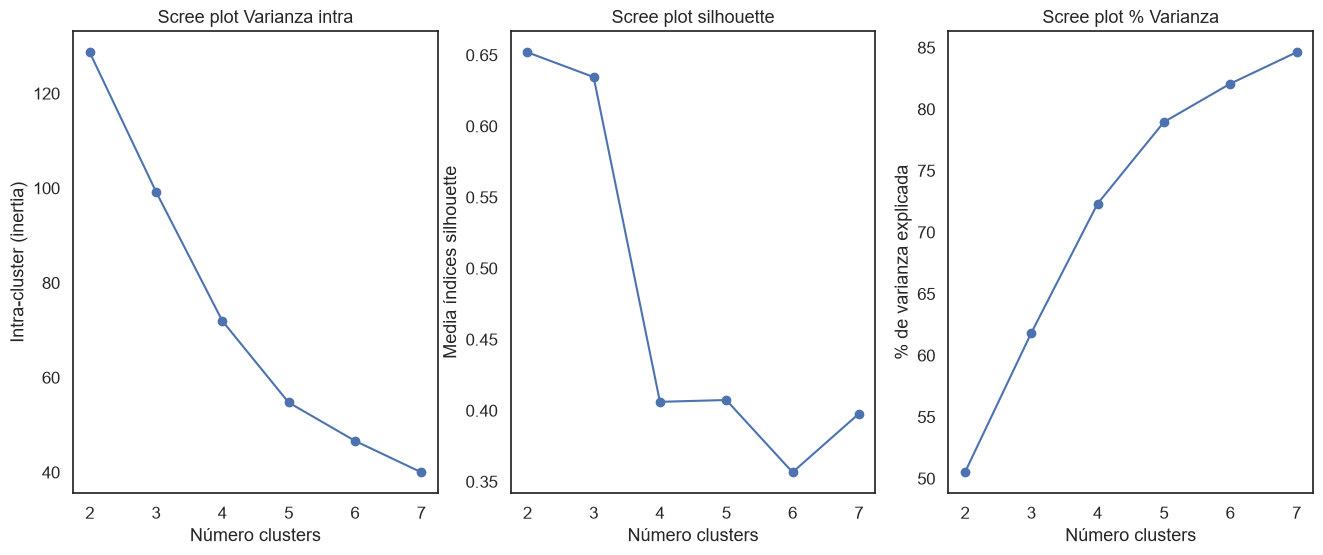

In [556]:
# Formula para revisar metricas
scree_plot_kmeans(X, n_max=8)

En el momento de elaboración del actual cuaderno, los valores idóneos se encuentran en k= 4/5, con valores cercanos a 0.38

Nos decantamos por seleccionar 4 clusters (k=4).

In [557]:
# Entrenamos K means con 4 clusters

kmeans = KMeans(n_clusters=3, random_state=60, n_init=40)
TurismoProvincia['cluster_saturacion'] = kmeans.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, TurismoProvincia['cluster_saturacion'])

print(f"Nuevo Silhouette Score: {sil:.3f}")

Nuevo Silhouette Score: 0.586


Un silhouette score de 0,272 es un valor suficiente para validar el resultado alcanzado

In [558]:
# Pequeño bucle for para revisar las provincias y el cluster que se les ha asignado

for cl in range(4):
    provs = TurismoProvincia[TurismoProvincia['cluster_saturacion'] == cl]['provincia'].tolist()
    print(f'-- CLUSTER {cl} ({len(provs)} provincias) ---')
    print(', '.join(provs))
    print(' ')

-- CLUSTER 0 (42 provincias) ---
Araba/Álava, Albacete, Ávila, Badajoz, Burgos, Cáceres, Castelló/Castellón, Ciudad Real, Córdoba, A Coruña, Cuenca, Girona, Granada, Guadalajara, Gipuzkoa, Huelva, Huesca, Jaén, León, Lleida, La Rioja, Lugo, Madrid, Murcia, Navarra, Ourense, Asturias, Palencia, Pontevedra, Salamanca, Cantabria, Segovia, Sevilla, Soria, Tarragona, Teruel, Toledo, València/Valencia, Valladolid, Bizkaia, Zamora, Zaragoza
 
-- CLUSTER 1 (8 provincias) ---
Alacant/Alicante, Almería, Illes Balears, Barcelona, Cádiz, Málaga, Las Palmas, Santa Cruz de Tenerife
 
-- CLUSTER 2 (2 provincias) ---
Ceuta, Melilla
 
-- CLUSTER 3 (0 provincias) ---

 


Tras la revisión de las provincias, se puede observar una clara diferencia en los cuatro clusters creados, por lo que se les dará un nombre a cada uno

In [ ]:
Clusters = {0: 'Desaprovechado', #Albacete
            1: 'Saturados', # Baleares
            2: 'Grandes metrópolis', # Madrid
            3: 'Destinos maduros' # Alicante
            }

#Asignamos el nombre del cluster
TurismoProvincia['saturacion'] = TurismoProvincia['cluster_saturacion'].map(Clusters).astype('category')

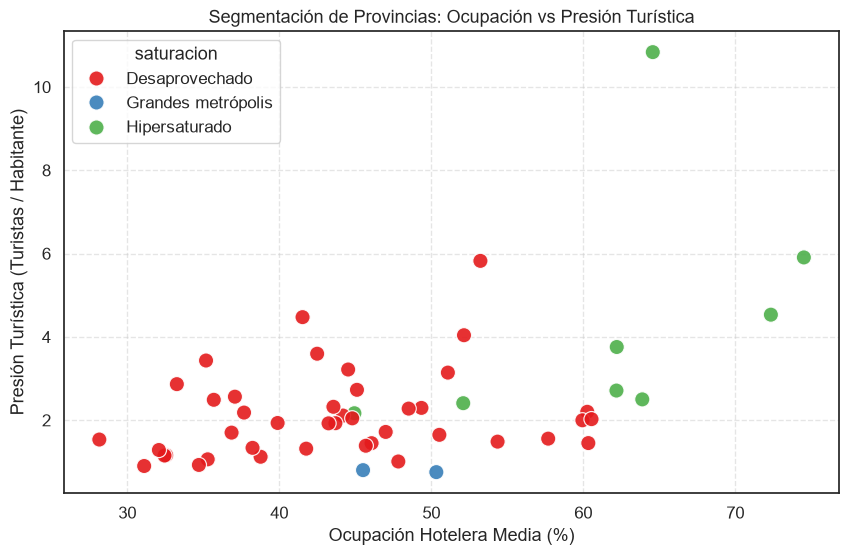

In [560]:
# Grafico de dispersion

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=TurismoProvincia,
    x='ocupacion_hotel_media',
    y='presion_turistica_hab',
    hue='saturacion',
    palette='Set1',
    s=120,
    alpha=0.9
)
plt.title('Segmentación de Provincias: Ocupación vs Presión Turística')
plt.xlabel('Ocupación Hotelera Media (%)')
plt.ylabel('Presión Turística (Turistas / Habitante)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Observando el gráfico de dispersión sobre ocupación hotelera es cierto que encontramos algunas "zonas grises", especialmente entre los destinos desaprovechados y maduros, y las grandes ciudades con los destinos maduros.

Aprovechando que es un GeoDataFrame, vamos a observar esta catalogación en un mapa de España.

**Objeto 1:** Mapa de España según cluster de saturación

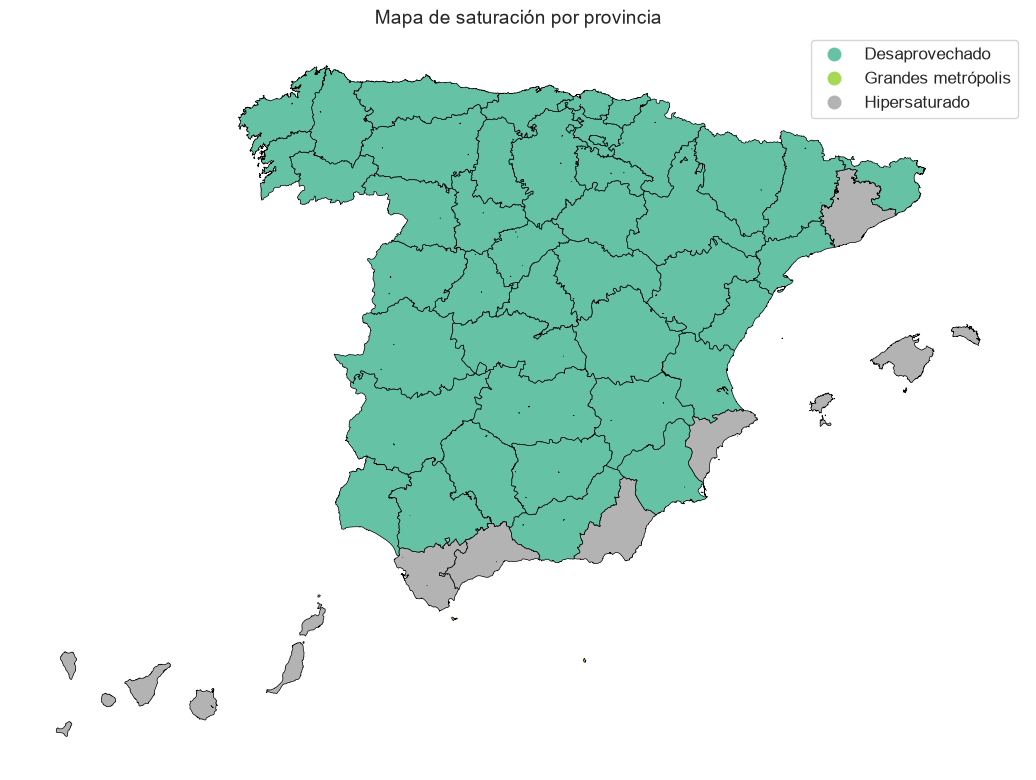

In [561]:
# Cruzamos los clusters con la cartografía provincial (mapa por provincias)
Map_prov.columns = Map_prov.columns.str.strip().str.lower()
mapa_clusters = Map_prov.merge(TurismoProvincia[['cod_prov', 'saturacion']], on='cod_prov', how='left')

# Definimos imagen
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_clusters.plot(
    column='saturacion',
    categorical=True,
    cmap='Set2',
    legend=True,
    linewidth=0.5,
    edgecolor='black',
    ax=ax,
)
ax.set_title('Mapa de saturación por provincia', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

Este visual nos da una imagen mucho más clara de la división categórica:

* **0: Desaprovechados.** Destinos generalmente de interior peninsular sin movimientos turísticos importantes
* **1: Hipersaturados.** Destinos con un alto grado de ocupación, que se ve reflejado en el coste por habitación (``ADR``). principalmente archipielagos exceptuando Málaga.
* **2: Grandes metropolis.** Las dos grandes ciudades de España, con cualidades únicas, una tasa de ocupación alta acompañada de un nivel un gran margen de ocupación en temporadas valle.
* **3: Destinos maduros.** Destinos con acceso al mar (exceptuando Sevilla), con alta ocupación en temporada alta.

Tras comprobar el éxito de este primer cluster, vamos a desarrollar el segundo más centrado en el potencial de cada provincia

In [562]:
OfertaOSM.head()

categoria,cod_prov,provincia,alojamiento,cultura,ocio,restauracion,servicios turisticos,turismo general
0,01,Araba/Álava,136,137,165,1033,5,0
1,02,Albacete,202,90,146,649,0,0
2,03,Alicante/Alacant,727,430,498,5145,10,0
3,04,Almería,307,188,247,1388,7,0
4,05,Ávila,246,106,127,437,7,0


## Cluster 2 Potencial turístico por provincia 

Para realizar el estudio del potencial turístico, vamos a basarnos en la información trbajada en ``OfertaOSM``, especialmente en las columnas de ocio cultura y restauracion.

Como el proceso es idéntico al cluster 1, se va a agilizar la elaboración, no sin mencionar que comenzaremos elaborando métricas dedicadas

In [563]:
OfertaOSM.cod_prov.info() #Vemos que es str, por lo que para realizar el merge tendremos que transformarlo

<class 'pandas.Series'>
RangeIndex: 52 entries, 0 to 51
Series name: cod_prov
Non-Null Count  Dtype
--------------  -----
52 non-null     str  
dtypes: str(1)
memory usage: 659.0 bytes


In [564]:
#Unimos TurismoProvincia con las métricas territoriales del nuevo OfertaOSM
OfertaOSM['cod_prov'] = OfertaOSM['cod_prov'].astype('Int64')

TurismoPotencial = TurismoProvincia.merge(
    OfertaOSM[['cod_prov', 'cultura', 'ocio', 'restauracion']],
    on='cod_prov',
    how='left'
).fillna(0)

# Construimos el DataFrame específico de Potencial
df_potencial = pd.DataFrame() #Creamos df vacío
df_potencial[['cod_prov','provincia']] = TurismoPotencial[['cod_prov','provincia']]

# Variables de capacidad y margen, seleccionadas tras varias pruebas con diferentes variables

# Capacidad rural (plazas * (1 - ocupacion))
df_potencial['capacidad_rural_libre'] = TurismoPotencial['plazas_rural_media'] * (1 - TurismoPotencial['ocupacion_rural_media'] / 100.0)

# Capacidad hotel (plazas * (1- ocupacion))
df_potencial['margen_hotel_valle'] = TurismoPotencial['plazas_hotel_media'] * (1 - TurismoPotencial['ocupacion_hotel_media'] / 100.0)

# Duracion estancia
df_potencial['estancia_media_rural'] = TurismoPotencial['estancia_media_rural']



# Variables de OSM en escala logarítmica (tras varias pruebas, se ha decidido que es lo más acertado)
# Sumamos Cultura y Ocio como activos de atracción global (equivalente a atracciones + museos de toda la provincia)
df_potencial['cultura_ocio_log'] = np.log1p(
    TurismoPotencial['cultura'] + TurismoPotencial['ocio'])

df_potencial['restauracion_log'] = np.log1p(TurismoPotencial['restauracion'])



# StandardScaler
X_pot = df_potencial.drop(columns=['cod_prov', 'provincia']) #Quitamos variables string

scaler_pot = StandardScaler()
X_pot_scaled = scaler_pot.fit_transform(X_pot)

X_pot_scaled = pd.DataFrame(X_pot_scaled, columns=X_pot.columns, index=df_potencial['provincia'])

# Revisamos
print('Potencial preparado para aplicar Kmeans: ')
X_pot_scaled.head()

Potencial preparado para aplicar Kmeans: 


,capacidad_rural_libre,margen_hotel_valle,estancia_media_rural,cultura_ocio_log,restauracion_log
provincia,,,,,
Araba/Álava,-0.967232,-0.692178,0.128680,-0.761808,-0.138130
Albacete,0.956350,-0.583900,0.502311,-1.074079,-0.550549
Alacant/Alicante,-0.651350,1.149481,-0.041152,0.662281,1.287586
Almería,-0.771367,0.195917,0.094714,-0.299250,0.124085
Ávila,1.211463,-0.652583,-0.041152,-1.090271,-0.901254


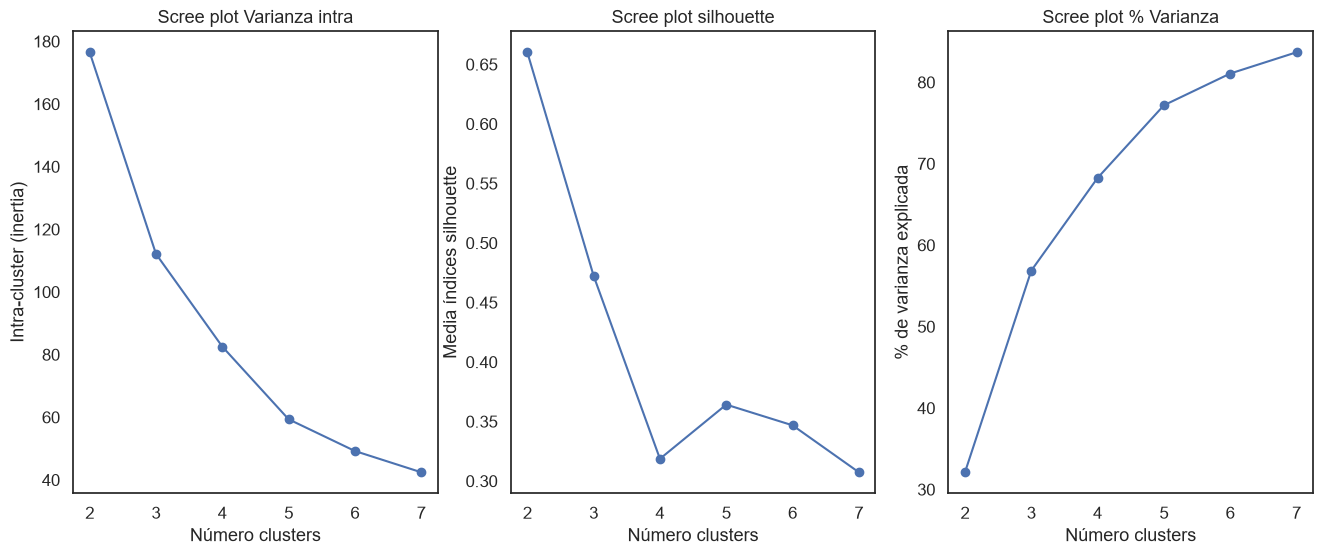

In [565]:
# Evaluamos el número óptimo de clusters para la dimensión de Potencial
scree_plot_kmeans(X_pot_scaled, n_max=8)

El nivel óptimo vuelve a ser 4/5 cluusters, ya que se situa en valores entre 0,2 y 0,4

In [566]:
# Repetimos con k=4
kmeans_pot = KMeans(n_clusters=4, random_state=42, n_init=20)
df_potencial['cluster_potencial'] = kmeans_pot.fit_predict(X_pot_scaled)

#Silhouette score
sil_pot = silhouette_score(X_pot_scaled, df_potencial['cluster_potencial'])
print(f"Silhouette Score final (Cluster Potencial k=4): {sil_pot:.3f}\n")


# Bucle para explorar visualmente el potencial de las provincias
for cl in sorted(df_potencial['cluster_potencial'].unique()):
    provs = df_potencial[df_potencial['cluster_potencial'] == cl]['provincia'].tolist()
    print(f"--- CLUSTER {cl}: ({len(provs)} provincias) ---")
    print(", ".join(provs))
    print(" ")

Silhouette Score final (Cluster Potencial k=4): 0.319

--- CLUSTER 0: (23 provincias) ---
Araba/Álava, Albacete, Ávila, Badajoz, Cáceres, Ciudad Real, Córdoba, Cuenca, Guadalajara, Huelva, Jaén, León, La Rioja, Lugo, Ourense, Palencia, Salamanca, Segovia, Soria, Teruel, Toledo, Valladolid, Zamora
 
--- CLUSTER 1: (6 provincias) ---
Illes Balears, Barcelona, Girona, Madrid, Málaga, Asturias
 
--- CLUSTER 2: (21 provincias) ---
Alacant/Alicante, Almería, Burgos, Cádiz, Castelló/Castellón, A Coruña, Granada, Gipuzkoa, Huesca, Lleida, Murcia, Navarra, Las Palmas, Pontevedra, Santa Cruz de Tenerife, Cantabria, Sevilla, Tarragona, València/Valencia, Bizkaia, Zaragoza
 
--- CLUSTER 3: (2 provincias) ---
Ceuta, Melilla
 


Creamos un diccionario para etiquetar cada cluster tras la exploración visual

In [567]:
# Diccionaro para asignar cluster
NombresPotencial = {
    0: 'Potencial bajo', #Albacete
    1: 'Destinos estrella', # Baleares, Madrid, Asturias
    2: 'Potencial alto', # Coruña
    3: 'Ciudades pequeñas' #Ceuta y Melilla
}

#Aplicamos
df_potencial['potencial'] = df_potencial['cluster_potencial'].map(NombresPotencial).astype('category')

Por último, añadimos los clusters al dataframe principal

In [568]:
TurismoProvincia['cluster_potencial'] = df_potencial['cluster_potencial']
TurismoProvincia['potencial'] = df_potencial['potencial']

**Objeto 2** Mapa de potencial turístico por provincia

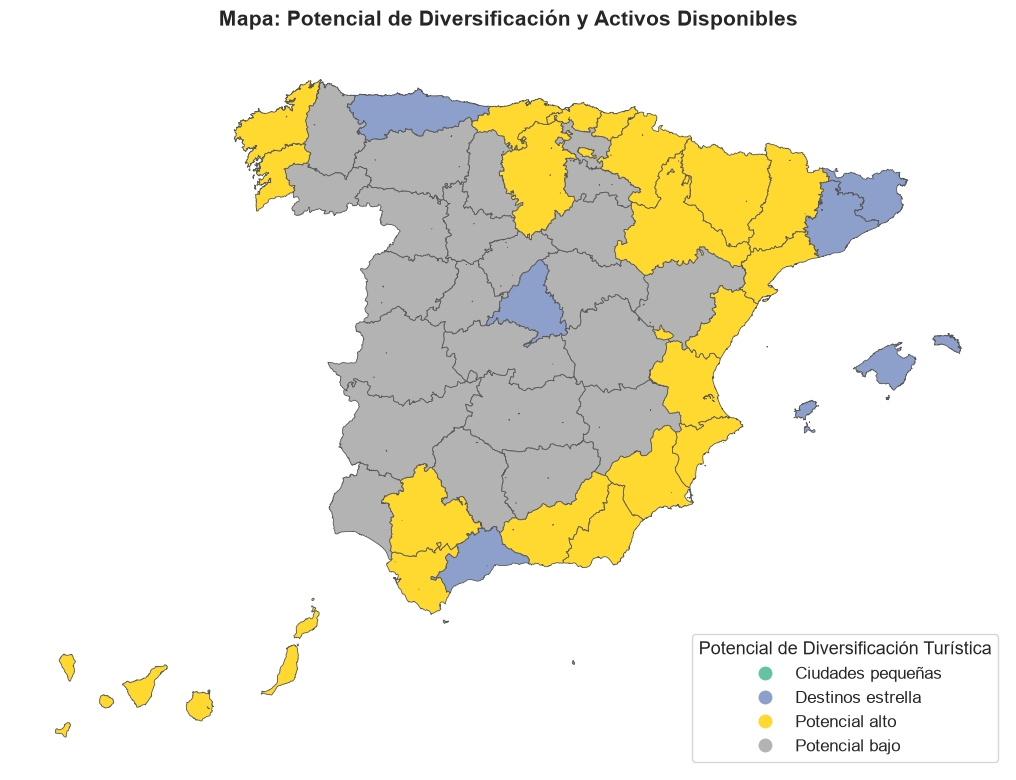

In [569]:
# Cruzamos el cluster de potencial con la cartografía provincial
mapa_potencial = Map_prov.merge(TurismoProvincia[['cod_prov', 'potencial']], on='cod_prov', how='left')

fig, ax = plt.subplots(1, 1, figsize=(13, 8))
mapa_potencial.plot(
    column='potencial',
    categorical=True,
    legend=True,
    cmap='Set2',
    edgecolor='0.35',
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        'loc': 'lower right',
        'title': "Potencial de Diversificación Turística",
        'frameon': True
    }
)

ax.set_title("Mapa: Potencial de Diversificación y Activos Disponibles", fontsize=15, weight='bold', pad=15)
ax.axis('off')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

**Objeto 3:** Matriz de decisión; provincias según su saturación y potencial

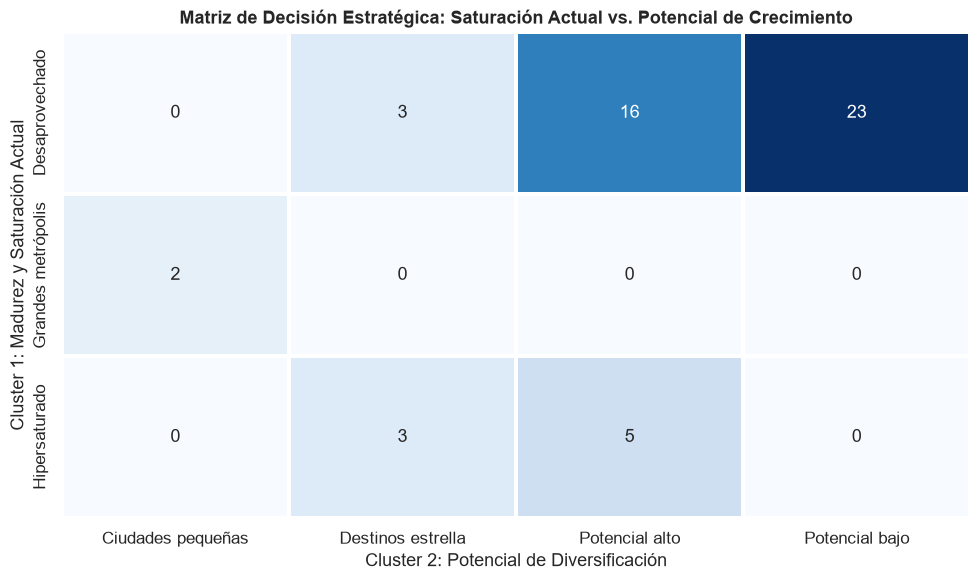

In [570]:
# Matriz de contingencia: Saturación actual vs Potencial de activos
matriz_cruce = pd.crosstab(
    TurismoProvincia['saturacion'], 
    TurismoProvincia['potencial'], 
    margins=True, 
    margins_name="Total"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pd.crosstab(TurismoProvincia['saturacion'], TurismoProvincia['potencial']),
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1.5
)
plt.title("Matriz de Decisión Estratégica: Saturación Actual vs. Potencial de Crecimiento", fontsize=13, weight='bold')
plt.xlabel("Cluster 2: Potencial de Diversificación")
plt.ylabel("Cluster 1: Madurez y Saturación Actual")
plt.tight_layout()
plt.show()



## Exploración y graficación

**Objeto 4** ADR por provincia según su cluster de saturación. Incluimos una línea que marque la media y otra con la mediana

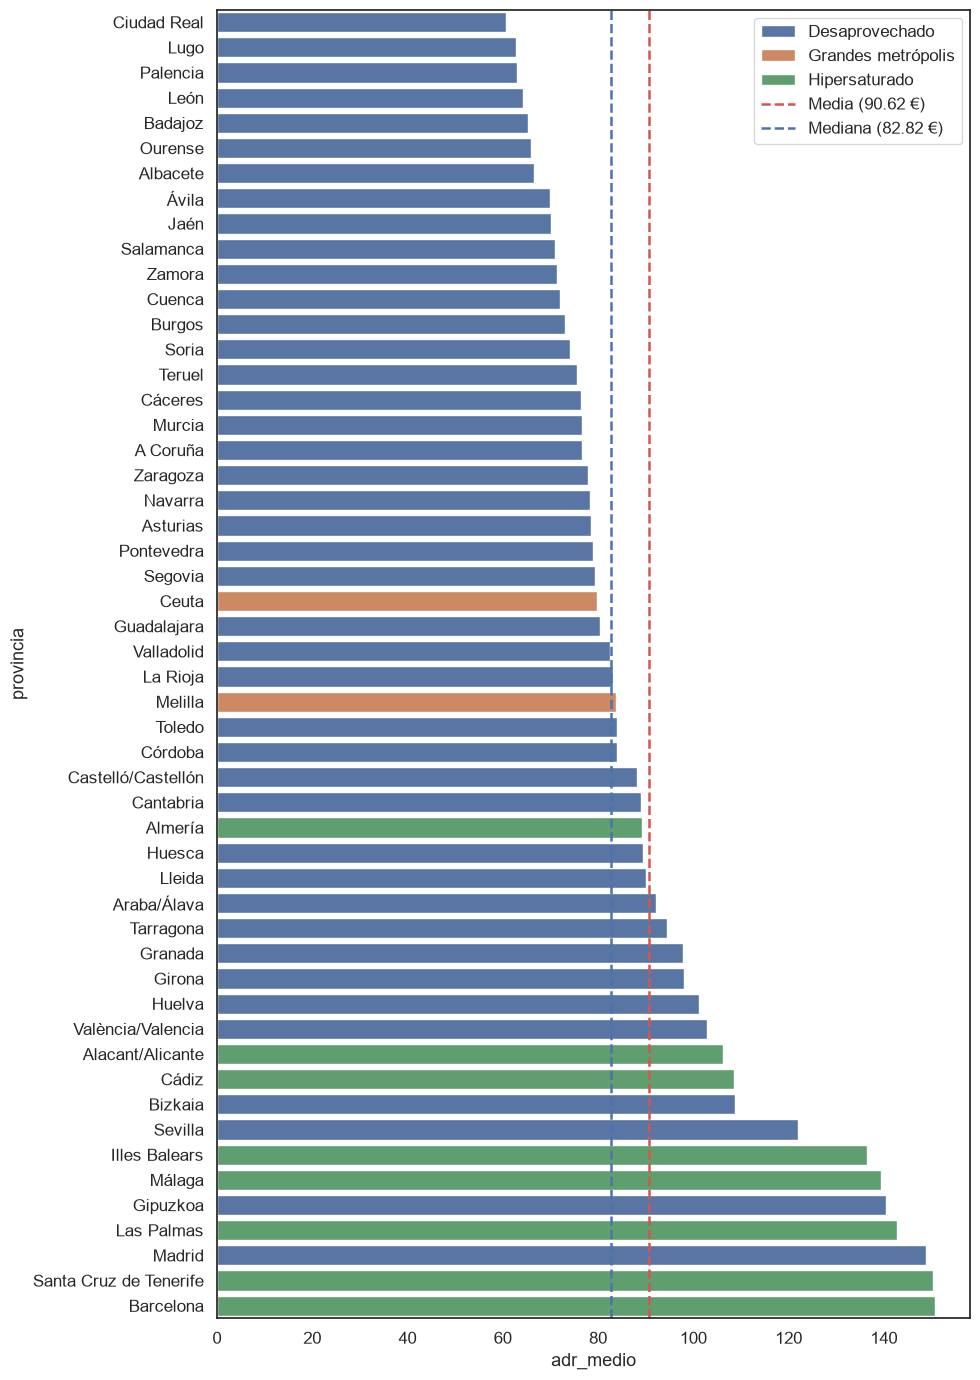

In [571]:
#Media y mediana para incluir en grafico
media_adr = TurismoProvincia['adr_medio'].mean()
mediana_adr = TurismoProvincia['adr_medio'].median()

plt.figure(figsize=(10, 14)) #Mas largo para visualizar correctamente cada provincia
sns.barplot(data=TurismoProvincia.sort_values(by='adr_medio'), 
            y='provincia', 
            hue='saturacion', 
            x='adr_medio', 
            dodge=False )

#Lineas de media y mediana
plt.axvline(
    x=media_adr,
    color='#d9534f', #Rojo
    linestyle='--',
    linewidth=1.8,
    label=f'Media ({media_adr:.2f} €)'
)

plt.axvline( #Color azul de serie
    x=mediana_adr,
    linestyle='--',
    linewidth=1.8,
    label=f'Mediana ({mediana_adr:.2f} €)'
)

#Otros ajustes y .show()
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Objeto 5** Mapa de alojamientos de España

Ejemplo de gráfico usando uno de los valores que empleamos inicialmente

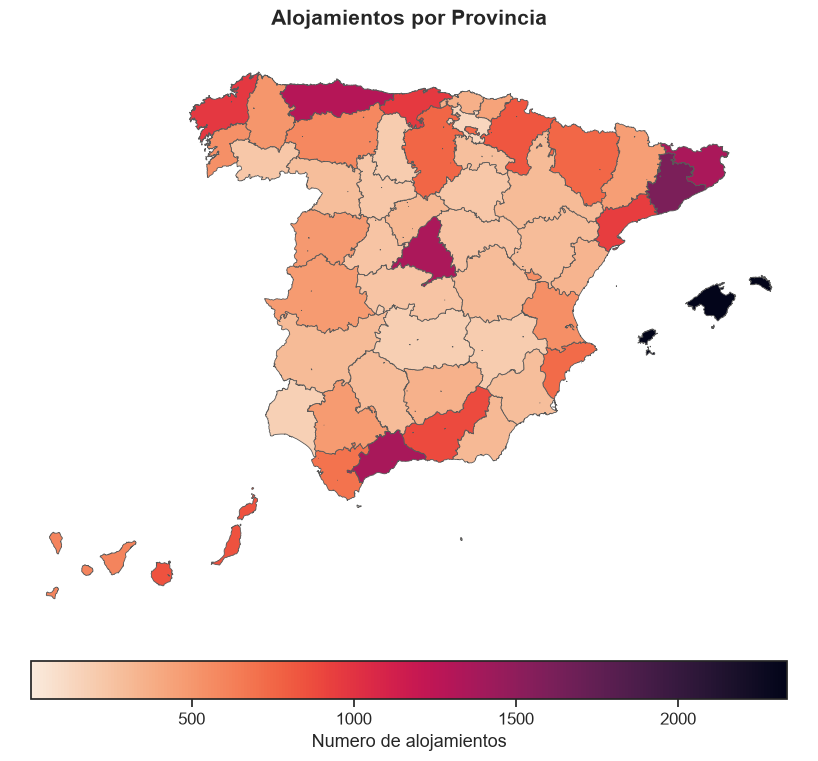

In [572]:

# estética
sns.set_theme(style="white", font_scale=1.1)

# Cargamos en un nuevo GDF para no modificar
gdf_muni = Map_muni.copy()
gdf_muni['COD_PROV'] = gdf_muni['COD_PROV'].astype(int)
gdf_provincias = gdf_muni.dissolve(by='COD_PROV', as_index=False)

# Unimos con OfertaOSM
gdf_prov_analisis = gdf_provincias.merge(
    OfertaOSM[['cod_prov', 'alojamiento']],
    left_on='COD_PROV', 
    right_on='cod_prov', 
    how='inner'
)

# 4. Creamos variable para el color
cmap_seaborn = sns.color_palette("rocket_r", as_cmap=True)


fig, ax = plt.subplots(1, 1, figsize=(13, 8))

# Pintamos el mapa
gdf_prov_analisis.plot(
    column='alojamiento',
    cmap=cmap_seaborn,
    legend=True,
    edgecolor='0.35',
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        'label': "Numero de alojamientos",
        'orientation': "horizontal",
        'shrink': 0.6,
        'pad': 0.05
    }
)

# Ajustes de sns
ax.set_title("Alojamientos por Provincia", fontsize=15, weight='bold', pad=15)
ax.axis('off')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Guardado de dataframes con creados, en un unico dataframe 

In [573]:
carpeta = Path('Datos procesados/Datos pulidos')
carpeta.mkdir(parents=True, exist_ok=True) # Por si no existe, se crea la carpeta


TurismoProvincia.to_csv(carpeta  / 'TurismoProvincia.csv', index=False, sep=';', encoding='UTF-8')